In [1]:
import psycopg2
import pandas as pd

# Database connection parameters
db_params = {
    'host': '194.171.191.226',
    'port': ' 6379',  
    'database': 'postgres',
    'user': 'group15',
    'password': 'blockd_2024group15_73'
}

# Create a cursor object
conn = psycopg2.connect(**db_params)
cursor = conn.cursor()

# Execute the query
query = "SELECT * from data_lake.accident_data_17_23"
cursor.execute(query)

# Step 3: Commit the transaction
conn.commit()
print("Query executed successfully!")

# Fetch the results
columns = [desc[0] for desc in cursor.description]
result1 = [{columns[index]: column for index, column in enumerate(value)} for value in cursor.fetchall()]

# Convert the result to a Pandas DataFrame
result1 = pd.DataFrame(result1)



Query executed successfully!


In [2]:
result1.head()

,Year,Accident severity,municipality,town,First Mode of Transport,Second mode of Transport,Area Type,Light condition,Road Location,Road condition,Road surface,Road situation,Speed limit,street,weather,accidents
0,2017,Fatal,Breda,BREDA,Car,Pedestrian,Urban area,Darkness,Intersection,Wet/damp,Brick,Bend,30 km/h,Valkeniersplein,Rain,1
1,2017,Fatal,Breda,BREDA,Lorry,Other,Urban area,Daylight,Intersection,Wet/damp,Brick,Intersection - 4 arms,50 km/h,Markendaalseweg,Dry,1
2,2017,Fatal,Breda,BREDA,Lorry,Other,Urban area,Daylight,Road section,Dry,Asphalt (other),Straight road,50 km/h,Academiesingel,Dry,1
3,2017,Injured,Breda,BAVEL,Car,Lorry,Rural area,Darkness,Road section,Wet/damp,Asphalt (other),Bend,120 km/h,KP ST.ANNABOSCH,Dry,1
4,2017,Injured,Breda,BAVEL,Car,Other,Rural area,Darkness,Road section,Wet/damp,Porous asphalt,Straight road,130 km/h,RYKSWG,Rain,1


In [3]:
# Step 2: Execute SQL command to create the table
create_table_query = '''
SELECT * from data_lake.safe_driving;
'''
cursor.execute(create_table_query)
# Step 3: Commit the transaction
conn.commit()
print("Query executed successfully!")
columns = cursor.description
result2 = [{columns[index][0]: column for index, column in enumerate(value)} for value in cursor.fetchall()]
result2 = pd.DataFrame(result2)

Query executed successfully!


In [4]:
result2.head()

,eventid,event_start,event_end,duration_seconds,latitude,longitude,speed_kmh,end_speed_kmh,maxwaarde,category,incident_severity,is_valid,road_segment_id,road_manager_type,road_number,road_name,place_name,municipality_name,road_manager_name
0,39325035,2019-11-12 23:44:16.000,2019-11-12 23:44:31.000,15.0,51.588940,4.834780,64.497710,61.740105,70.401720,SPEED,SP1,True,233200001,G,,Minervum,Breda,Breda,Breda
1,38868502,2019-11-12 16:39:41.500,2019-11-12 16:39:51.500,10.0,51.602370,4.812593,41.842945,41.842945,45.061630,SPEED,SP1,True,600438111,G,,Burgemeester Verdaasdonkstraat,Teteringen,Breda,Breda
2,39379704,2019-11-12 16:51:10.600,2019-11-12 16:51:13.300,2.7,51.589250,4.763880,31.136452,28.090849,0.778922,HARSH CORNERING,HC1,True,223200132,G,,Lunetbrug,Breda,Breda,Breda
3,39377265,2019-11-12 16:48:55.700,2019-11-12 16:48:56.100,0.4,51.572807,4.805721,46.620075,30.996052,0.844906,BRAKING,HB1,True,601074884,G,,Zwijnsbergenstraat,Breda,Breda,Breda
4,38053382,2019-11-12 15:32:51.500,2019-11-12 15:32:59.500,8.0,51.599670,4.799308,41.842945,41.842945,46.670975,SPEED,SP1,True,228202081,G,,Baliëndijk,Breda,Breda,Breda


In [5]:
conn_psycopg2 = psycopg2.connect(**db_params)
cursor = conn_psycopg2.cursor()
create_table_query = '''
SELECT TRIM(category) as category,
       TRIM(incident_severity) as incident_severity,
       COUNT(*) as tot_count
FROM data_lake.safe_driving
WHERE is_valid='True'
GROUP BY 1, 2
ORDER BY tot_count desc;
'''
cursor.execute(create_table_query)
columns = cursor.description
result3 = [{columns[index][0]: column for index, column in enumerate(value)} for value in cursor.fetchall()]
result3 = pd.DataFrame(result3)
conn_psycopg2.close()
result3.head()

,category,incident_severity,tot_count
0,HARSH CORNERING,HC1,396023
1,SPEED,SP1,356892
2,SPEED,SP2,27289
3,BRAKING,HB1,26740
4,HARSH CORNERING,HC2,4047


In [6]:
conn_psycopg2 = psycopg2.connect(**db_params)
# Step 1: Create a cursor object
cursor = conn_psycopg2.cursor()
create_table_query = '''
-- Always include drop statement before creating your custom tables
DROP TABLE IF EXISTS group15_warehouse.filtered_base_data;  -- Drop if exists
CREATE TABLE group15_warehouse.filtered_base_data AS (
    SELECT * FROM data_lake.safe_driving
    WHERE is_valid='True'
    AND trim(incident_severity) IN ('HC1','HC2','SP1','SP2','HB1')
);
'''
cursor.execute(create_table_query)
# Step 3: Commit the transaction
conn_psycopg2.commit()
print("Query executed successfully!") 

# Execute a SELECT statement on the newly created table
select_query = "SELECT * FROM group15_warehouse.filtered_base_data"
cursor.execute(select_query)

#columns = [desc[0] for desc in cursor.description]
#result4 = [dict(zip(columns, row)) for row in cursor.fetchall()]
#result4 = pd.DataFrame(result4)

#result4.head()

conn_psycopg2.close()

Query executed successfully!


In [7]:
# Step 2: Execute SQL command to create the table
# Method 1: Psycopg2
conn_psycopg2 = psycopg2.connect(**db_params)
cursor = conn_psycopg2.cursor()

create_table_query = '''
select count(*) from group15_warehouse.filtered_base_data;
'''

cursor.execute(create_table_query)

# Step 3: Commit the transaction
conn_psycopg2.commit()
print("Query executed successfully!")
columns = cursor.description
result3 = [{columns[index][0]: column for index, column in enumerate(value)} for value in cursor.fetchall()]
result3 = pd.DataFrame(result3) 

conn_psycopg2.close()

Query executed successfully!


In [8]:
result3

,count
0,810991


In [9]:
# Step 2: Execute SQL command to create the table
# Method 1: Psycopg2
conn_psycopg2 = psycopg2.connect(**db_params)
# Step 1: Create a cursor object
cursor = conn_psycopg2.cursor()
create_table_query = '''
select * from data_lake.accident_data_17_23 limit 10;
'''
cursor.execute(create_table_query)
# Step 3: Commit the transaction
conn_psycopg2.commit()
print("Query executed successfully!")
columns = cursor.description
result3 = [{columns[index][0]: column for index, column in enumerate(value)} for value in cursor.fetchall()]
result3 = pd.DataFrame(result3)
conn_psycopg2.close()
result3

Query executed successfully!


,Year,Accident severity,municipality,town,First Mode of Transport,Second mode of Transport,Area Type,Light condition,Road Location,Road condition,Road surface,Road situation,Speed limit,street,weather,accidents
0,2017,Fatal,Breda,BREDA,Car,Pedestrian,Urban area,Darkness,Intersection,Wet/damp,Brick,Bend,30 km/h,Valkeniersplein,Rain,1
1,2017,Fatal,Breda,BREDA,Lorry,Other,Urban area,Daylight,Intersection,Wet/damp,Brick,Intersection - 4 arms,50 km/h,Markendaalseweg,Dry,1
2,2017,Fatal,Breda,BREDA,Lorry,Other,Urban area,Daylight,Road section,Dry,Asphalt (other),Straight road,50 km/h,Academiesingel,Dry,1
3,2017,Injured,Breda,BAVEL,Car,Lorry,Rural area,Darkness,Road section,Wet/damp,Asphalt (other),Bend,120 km/h,KP ST.ANNABOSCH,Dry,1
4,2017,Injured,Breda,BAVEL,Car,Other,Rural area,Darkness,Road section,Wet/damp,Porous asphalt,Straight road,130 km/h,RYKSWG,Rain,1
5,2017,Injured,Breda,BAVEL,Delivery van,Car,Rural area,Darkness,Road section,Wet/damp,Asphalt (other),Straight road,80 km/h,Gilzeweg,Rain,1
6,2017,Injured,Breda,BREDA,Bicycle,Motorcycle,Urban area,Daylight,Intersection,Dry,Asphalt (other),Intersection - 4 arms,50 km/h,Nieuwe Kadijk,Dry,1
7,2017,Injured,Breda,BREDA,Bicycle,Other,Urban area,Daylight,Intersection,Dry,Asphalt (other),Intersection - 4 arms,30 km/h,Rithsestraat,Dry,1
8,2017,Injured,Breda,BREDA,Bicycle,Other,Urban area,Daylight,Intersection,Dry,Brick,Straight road,Unknown,Steenbroek,Dry,1
9,2017,Injured,Breda,BREDA,Bicycle,Other,Unknown,Darkness,Road section,Unknown,Unknown,Unknown,50 km/h,Achter Emer,Unknown,1


In [10]:
conn_psycopg2 = psycopg2.connect(**db_params)
# Step 1: Create a cursor object
cursor = conn_psycopg2.cursor()
create_table_query = '''
-- I have used complex sub queries, but I have commented wherever possible
-- write to me or ping me if you have queries, or if you find any issues in the query
select
TRIM(category) as category,
trim(incident_severity) as incident_severity,
COUNT(*) as tot_count
from
group15_warehouse.filtered_base_data a1
join
-- By using this join, the operation will be much faster, since we are technically filtering only data from anwb data
(
-- I have used the results as the "b" table temporarily to save space.
-- Below sub query will find the matching street names from the two tables
select anwb_road_name
from
( -- Sub Query to find the unique road names from the anwb data
select lower(road_name) anwb_road_name
from
group15_warehouse.filtered_base_data
group by 1
) a
where a.anwb_road_name in
(
-- Sub Query to find the unique road names from the new accident data
select lower(street) new_accident_street
from
data_lake.accident_data_17_23
group by 1
)
)b
-- joined on the road name with the larger base table to see the number of rows matching
-- see the results and the subsequent calculation to see whether our analysis is valid
on lower(a1.road_name)=b.anwb_road_name
group by 1,2
;
'''
cursor.execute(create_table_query)
# Step 3: Commit the transaction
conn_psycopg2.commit()
print("Query executed successfully!")
columns = cursor.description
result3 = [{columns[index][0]: column for index, column in enumerate(value)} for value in cursor.fetchall()]
result3 = pd.DataFrame(result3)
conn_psycopg2.close()

Query executed successfully!


In [11]:
result3

,category,incident_severity,tot_count
0,SPEED,SP1,349587
1,HARSH CORNERING,HC2,3936
2,HARSH CORNERING,HC1,387624
3,BRAKING,HB1,25582
4,SPEED,SP2,26831


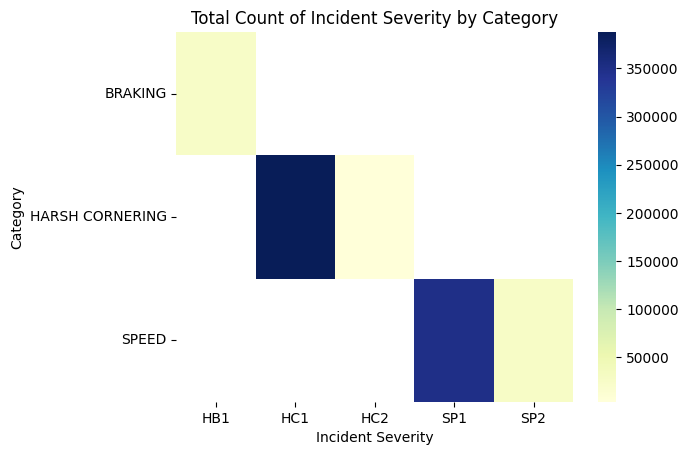

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

df = result3.copy() 

# Create a heatmap
sns.heatmap(df.pivot_table(values='tot_count', index='category', columns='incident_severity'), cmap='YlGnBu')

# Add a title and labels
plt.title('Total Count of Incident Severity by Category')
plt.xlabel('Incident Severity')
plt.ylabel('Category')

# Rotate the x-axis labels (category index) by 90 degrees
plt.yticks(rotation=0)

# Show the plot
plt.show()